In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%cd /content/drive/MyDrive/Generalizable-DDA-RL


/content/drive/MyDrive/Generalizable-DDA-RL


### ***Install and Quick Check***

In [5]:
!pip install -q gymnasium stable-baselines3

import gymnasium
from gymnasium import spaces
import stable_baselines3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Gymnasium:", gymnasium.__version__)
print("Stable-Baselines3:", stable_baselines3.__version__)
print("NumPy:", np.__version__)
print("SUCCESS!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 7.2 MB/s eta 0:00:00
Gymnasium: 1.3.0
Stable-Baselines3: 2.9.0
NumPy: 2.1.3
SUCCESS!


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### ***Required Folders***

In [6]:
!mkdir -p models
!mkdir -p results/training
!mkdir -p results/figures
!mkdir -p results/tables

print("Folders Ready!")

Folders Ready!


### ***Import Environment***

In [7]:
from src.environment import GADDAEnv

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

print("Imports Successful!")

Imports Successful!


### ***Randomised Training Environment***

In [8]:
import numpy as np
import gymnasium as gym

from src.environment import GADDAEnv


class RandomPlayerWrapper(gym.Env):
    """
    Samples a different player profile
    at the beginning of each episode.
    """

    def __init__(
        self,
        max_steps=200,
        target_win_rate=0.70,
        seed=42
    ):

        self.max_steps = max_steps

        self.target_win_rate = target_win_rate

        self.seed_value = seed

        self.env = None

        self.action_space = None

        self.observation_space = None

        self._create_environment()


    def _sample_player_config(self):

        profile_type = np.random.choice(

            [
                "stable",
                "learning",
                "fatigue",
                "noisy"
            ]

        )


        if profile_type == "stable":

            return {

                "initial_skill":
                    float(
                        np.random.uniform(
                            0.35,
                            0.70
                        )
                    ),

                "learning_rate":
                    0.0,

                "fatigue_rate":
                    0.0,

                "noise_std":
                    0.05
            }


        elif profile_type == "learning":

            return {

                "initial_skill":
                    float(
                        np.random.uniform(
                            0.25,
                            0.50
                        )
                    ),

                "learning_rate":
                    float(
                        np.random.uniform(
                            0.001,
                            0.004
                        )
                    ),

                "fatigue_rate":
                    0.0,

                "noise_std":
                    0.05
            }


        elif profile_type == "fatigue":

            return {

                "initial_skill":
                    float(
                        np.random.uniform(
                            0.60,
                            0.85
                        )
                    ),

                "learning_rate":
                    0.0,

                "fatigue_rate":
                    float(
                        np.random.uniform(
                            0.001,
                            0.003
                        )
                    ),

                "noise_std":
                    0.05
            }


        else:

            return {

                "initial_skill":
                    float(
                        np.random.uniform(
                            0.35,
                            0.70
                        )
                    ),

                "learning_rate":
                    0.0,

                "fatigue_rate":
                    0.0,

                "noise_std":
                    float(
                        np.random.uniform(
                            0.08,
                            0.15
                        )
                    )
            }


    def _create_environment(self):

        player_config = (
            self._sample_player_config()
        )


        self.env = GADDAEnv(

            max_steps=
                self.max_steps,

            target_win_rate=
                self.target_win_rate,

            player_config=
                player_config,

            seed=
                self.seed_value
        )


        self.action_space = (
            self.env.action_space
        )

        self.observation_space = (
            self.env.observation_space
        )


    def reset(
        self,
        seed=None,
        options=None
    ):

        if seed is not None:

            self.seed_value = seed


        self._create_environment()


        return self.env.reset(
            seed=seed,
            options=options
        )


    def step(
        self,
        action
    ):

        return self.env.step(
            action
        )

### ***Testing Randomised Environment***

In [9]:
env = RandomPlayerWrapper(
    max_steps=200,
    target_win_rate=0.70,
    seed=42
)

observation, info = env.reset(
    seed=42
)

print("Observation:", observation)

print(
    "Observation space:",
    env.observation_space
)

print(
    "Action space:",
    env.action_space
)

print("Random Environment Works :)")

Observation: [0.3867008 0.5       0.5       0.7       0.5      ]
Observation space: Box(0.0, 1.0, (5,), float32)
Action space: Box(0.0, 1.0, (1,), float32)
Random Environment Works :)


In [10]:
env = RandomPlayerWrapper(
    max_steps=200,
    target_win_rate=0.70,
    seed=42
)

env = Monitor(
    env
)

print("Monitor Added!")

Monitor Added!


### ***Creating PPO Model***

In [11]:
from stable_baselines3 import PPO

model = PPO(
    policy="MlpPolicy",
    env=env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    verbose=1,
    seed=42,
    device="cpu"
)

print("PPO Model Created :)")

Using cpu device
Wrapping the env in a DummyVecEnv.
PPO Model Created :)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## ***Train PPO***

In [12]:
model.learn(
    total_timesteps=100_000
)

print(
    "PPO Training : Done!"
)

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | 125      |
| time/              |          |
|    fps             | 1205     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 200         |
|    ep_rew_mean          | 129         |
| time/                   |             |
|    fps                  | 887         |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.006598383 |
|    clip_fraction        | 0.0729      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.42       |
|    explained_variance   | 0.00437     |
|    learning_rate        | 0.

In [13]:
model.save(
    "models/ppo_dda"
)

print(
    "PPO Model has been Saved!"
)

PPO Model has been Saved!


In [14]:
!ls -lh models

total 141K
-rw------- 1 root root 141K Sep  8 18:03 ppo_dda.zip


In [15]:
from stable_baselines3 import PPO


loaded_model = PPO.load(
    "models/ppo_dda"
)

print(
    "Model Loaded!"
)

Model Loaded!


/usr/local/lib/python3.13/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


### **Evaluation of One PPO Episode**

In [16]:
test_env = GADDAEnv(

    max_steps=200,

    target_win_rate=0.70,

    player_config={

        "initial_skill":
            0.5,

        "learning_rate":
            0.0,

        "fatigue_rate":
            0.0,

        "noise_std":
            0.05
    },

    seed=123
)


observation, info = test_env.reset(
    seed=123
)


ppo_difficulties = []

ppo_win_rates = []

ppo_rewards = []


terminated = False

truncated = False


while not (
    terminated
    or
    truncated
):

    action, _states = (
        loaded_model.predict(

            observation,

            deterministic=True
        )
    )


    (
        observation,
        reward,
        terminated,
        truncated,
        info
    ) = test_env.step(
        action
    )


    ppo_difficulties.append(
        info["difficulty"]
    )

    ppo_win_rates.append(
        info[
            "recent_win_rate"
        ]
    )

    ppo_rewards.append(
        reward
    )


print(
    "Evaluation complete!"
)

print(
    "Total PPO Reward:",
    round(
        sum(
            ppo_rewards
        ),
        3
    )
)

Evaluation complete!
Total PPO Reward: 210.864


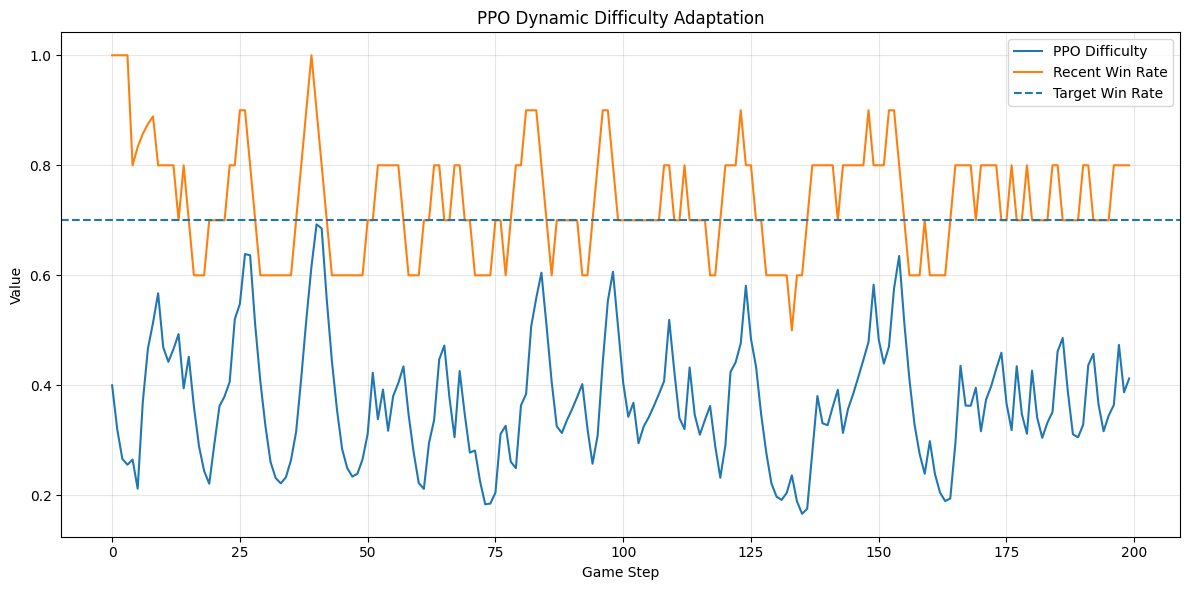

In [17]:
plt.figure(figsize=(12, 6))

plt.plot(
    ppo_difficulties,
    label="PPO Difficulty"
)

plt.plot(
    ppo_win_rates,
    label="Recent Win Rate"
)

plt.axhline(
    0.70,
    linestyle="--",
    label="Target Win Rate"
)

plt.xlabel(
    "Game Step"
)

plt.ylabel(
    "Value"
)

plt.title(
    "PPO Dynamic Difficulty Adaptation"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

### ***Let's FIX!***

In [18]:
!rm -f models/ppo_dda.zip

In [19]:
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

env = RandomPlayerWrapper(
    max_steps=200,
    target_win_rate=0.70,
    seed=42
)

env = Monitor(env)

model = PPO(
    policy="MlpPolicy",
    env=env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    verbose=1,
    seed=42,
    device="cpu"
)

print("PPO Model Created :)")

Using cpu device
Wrapping the env in a DummyVecEnv.
PPO Model Created :)


In [20]:
model.learn(
    total_timesteps=100_000
)

print("PPO training completed!")

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | 125      |
| time/              |          |
|    fps             | 937      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 200         |
|    ep_rew_mean          | 129         |
| time/                   |             |
|    fps                  | 837         |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.006598383 |
|    clip_fraction        | 0.0729      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.42       |
|    explained_variance   | 0.00437     |
|    learning_rate        | 0.

In [21]:
model.save("models/ppo_dda")

print("Model saved!")

Model saved!


In [22]:
import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3 import PPO
from src.environment import GADDAEnv


ppo_model = PPO.load(
    "models/ppo_dda",
    device="cpu"
)


test_env = GADDAEnv(
    max_steps=200,
    target_win_rate=0.70,
    player_config={
        "initial_skill": 0.5,
        "learning_rate": 0.0,
        "fatigue_rate": 0.0,
        "noise_std": 0.05
    },
    seed=123
)


obs, info = test_env.reset(seed=123)

ppo_difficulties = []
ppo_win_rates = []
ppo_rewards = []

terminated = False
truncated = False


while not (terminated or truncated):

    action, _ = ppo_model.predict(
        obs,
        deterministic=True
    )

    obs, reward, terminated, truncated, info = test_env.step(
        action
    )

    ppo_difficulties.append(
        info["difficulty"]
    )

    ppo_win_rates.append(
        info["recent_win_rate"]
    )

    ppo_rewards.append(
        reward
    )


print(
    "Total PPO Reward:",
    round(sum(ppo_rewards), 3)
)

print(
    "Mean PPO Difficulty:",
    round(np.mean(ppo_difficulties), 3)
)

print(
    "Final Win Rate:",
    round(ppo_win_rates[-1], 3)
)

print(
    "Mean Win Rate:",
    round(np.mean(ppo_win_rates), 3)
)

print(
    "Mean Win Rate Error:",
    round(
        np.mean(
            np.abs(
                np.array(ppo_win_rates) - 0.70
            )
        ),
        4
    )
)

Total PPO Reward: 210.864
Mean PPO Difficulty: 0.369
Final Win Rate: 0.8
Mean Win Rate: 0.733
Mean Win Rate Error: 0.0793


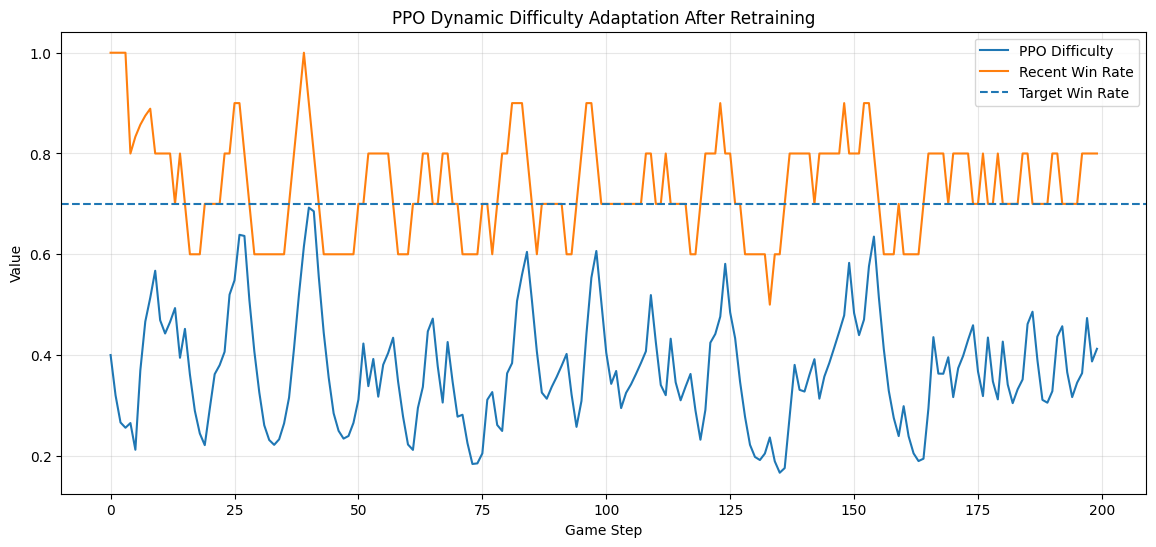

In [23]:
plt.figure(figsize=(14, 6))

plt.plot(
    ppo_difficulties,
    label="PPO Difficulty"
)

plt.plot(
    ppo_win_rates,
    label="Recent Win Rate"
)

plt.axhline(
    0.70,
    linestyle="--",
    label="Target Win Rate"
)

plt.xlabel("Game Step")
plt.ylabel("Value")

plt.title(
    "PPO Dynamic Difficulty Adaptation After Retraining"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()